# 01: Exploratory Data Analysis

Exploring the raw Kaggle "Give Me Some Credit" dataset before any cleaning.
Goal: understand the target, spot data quality issues, and gather the
evidence that justifies the cleaning decisions made in `02_preprocessing.ipynb`.

This notebook is read-only analysis. It doesn't produce any saved artifacts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/raw/cs-training.csv')
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

## Target variable

`SeriousDlqin2yrs`: 1 if the borrower became 90+ days delinquent within 2
years, else 0. Checking the class balance, since this drives modeling
decisions later (class weighting, stratified splitting).

In [3]:
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [4]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## Past-due columns: checking for sentinel/placeholder codes

`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, and
`NumberOfTime60-89DaysPastDueNotWorse` are counts of how many times a
borrower was late. `describe()` alone doesn't reveal rare extreme values;
visualizing and counting exact values does.

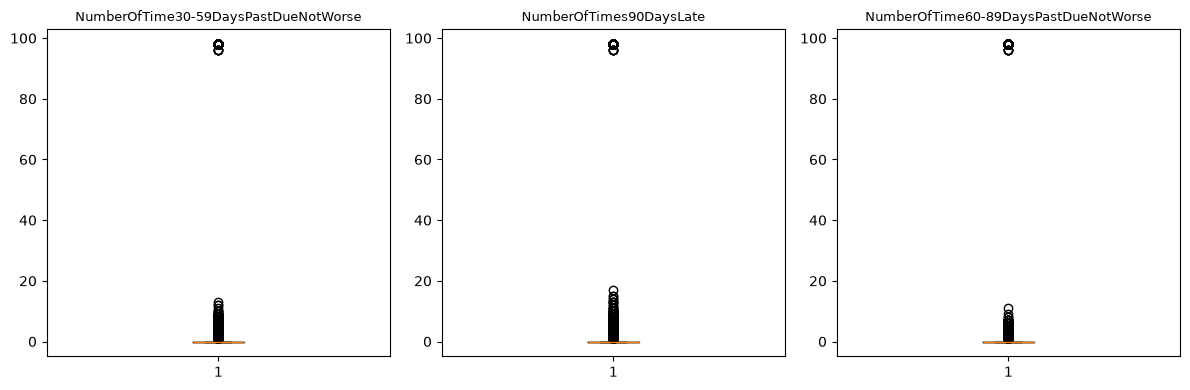

NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64



In [5]:
past_due_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, past_due_cols):
    ax.boxplot(df[col])
    ax.set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

for col in past_due_cols:
    print(col)
    print(df[col].value_counts().sort_index())
    print()

**Finding:** each column's value counts show a normal, steadily-decaying
distribution from 0 up to a low number (e.g. 13), then a complete gap, then
isolated values at 96 and 98. No real "number of times late" process
produces someone late 96 times but nobody late 20, 30, or 50 times. That
gap is the signature of a sentinel/placeholder code, not a genuine count.
Decision: these get replaced with 0 in preprocessing (see `02_preprocessing.ipynb`).

## RevolvingUtilizationOfUnsecuredLines and DebtRatio: extreme outliers

Both are meant to be ratios (roughly 0-1), but both have a max value in the
tens of thousands. Checking percentiles to see where "plausible" ends and
"implausible" begins.

In [6]:
print('RevolvingUtilizationOfUnsecuredLines')
for q in [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999, 0.9999, 1.0]:
    print(f"{q:>7.4f}: {df['RevolvingUtilizationOfUnsecuredLines'].quantile(q):.3f}")

print()
print('DebtRatio')
for q in [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999, 0.9999, 1.0]:
    print(f"{q:>7.4f}: {df['DebtRatio'].quantile(q):.3f}")

RevolvingUtilizationOfUnsecuredLines
 0.9000: 0.981
 0.9500: 1.000
 0.9700: 1.000
 0.9800: 1.006
 0.9900: 1.093
 0.9950: 1.366
 0.9990: 1571.006
 0.9999: 10151.006
 1.0000: 50708.000

DebtRatio
 0.9000: 1267.000
 0.9500: 2449.000
 0.9700: 3225.000
 0.9800: 3839.000
 0.9900: 4979.040
 0.9950: 6186.010
 0.9990: 10613.074
 0.9999: 40362.002
 1.0000: 329664.000


**Finding on `RevolvingUtilizationOfUnsecuredLines`:** a clean statistical
cliff. The 99.5th percentile is ~1.4 (plausible: someone slightly over their
credit limit), but the 99.9th percentile jumps to ~1571, a 1000x jump with
nothing in between. Consistent with a near-zero credit-limit denominator
artifact (balance ÷ ~0 explodes), not genuine spending behavior.

**Finding on `DebtRatio`:** no clean cliff. Percentiles climb gradually
into the thousands. Checking whether this correlates with something else,
specifically missing income (since DebtRatio = debt payments ÷ income, and
a broken/missing income denominator would explain implausibly large ratios).

In [7]:
bins = [0, 1, 2, 5, 10, 50, 100, 1000, float('inf')]
bucketed = pd.cut(df['DebtRatio'], bins=bins)
print(df.groupby(bucketed, observed=True)['MonthlyIncome'].apply(lambda s: s.isnull().mean()))
print()
print(df.groupby(bucketed, observed=True).size())

DebtRatio
(0.0, 1.0]         0.001851
(1.0, 2.0]         0.039101
(2.0, 5.0]         0.321658
(5.0, 10.0]        0.680104
(10.0, 50.0]       0.894665
(50.0, 100.0]      0.929858
(100.0, 1000.0]    0.908253
(1000.0, inf]      0.940800
Name: MonthlyIncome, dtype: float64

DebtRatio
(0.0, 1.0]         110750
(1.0, 2.0]           4092
(2.0, 5.0]           1399
(5.0, 10.0]           769
(10.0, 50.0]         2943
(50.0, 100.0]        1554
(100.0, 1000.0]      7488
(1000.0, inf]       16892
dtype: int64


**Finding:** a strong, monotonic correlation. Rows with `DebtRatio` in
(0,1] have only ~0.2% missing income, but by (1000, inf] that rises to
~94% missing. This gradual pattern (not a clean cliff) is why `DebtRatio`
gets simple 99th-percentile winsorization rather than a hand-picked cutoff,
combined with a separate `income_was_missing` flag (added in
preprocessing) that explicitly tells the model when a row's income-derived
features are untrustworthy, rather than relying on the cap alone to carry
that signal.

## Summary of decisions carried into `02_preprocessing.ipynb`

- Drop `Unnamed: 0` (index artifact from the CSV export)
- Add `income_was_missing` flag **before** imputing `MonthlyIncome`
- Replace sentinel codes 96/98 in the three past-due columns with 0
- Impute `age` (for 0-value rows), `MonthlyIncome`, `NumberOfDependents`
  with medians learned from training data only
- Winsorize `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` at the
  99th percentile, learned from training data only